Importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from itertools import product
import time
from prophet import Prophet
import logging

# Ignorer les warnings (convergence, etc.)
warnings.filterwarnings("ignore")

/Users/laurian/Documents/Cours/M2 Data Science/Capstone/env_Capstone/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Station P

### Rappels de nos données sensor_P

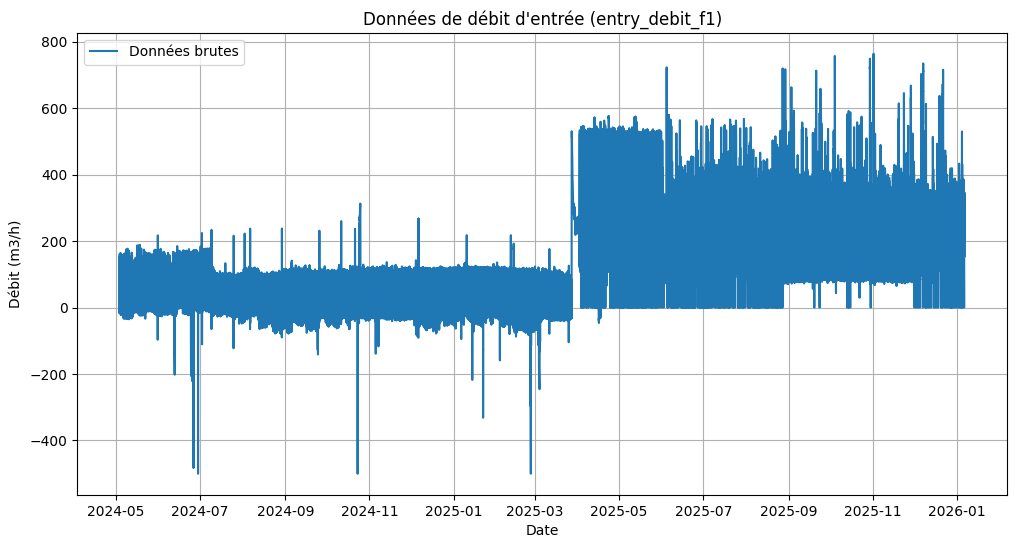

In [2]:
file_path = '../../Dataset/bronze/sensor_P_20231110_20260106.csv'
df = pd.read_csv(file_path)
data_col = 'ts'
df[data_col] = pd.to_datetime(df[data_col])
df.set_index(data_col, inplace=True)
data_clean = df.loc[df['sensor'] == 'entry_debit_f1', 'value']

fig = plt.figure(figsize=(12, 6))
plt.plot(data_clean, label='Données brutes')
plt.title('Données de débit d\'entrée (entry_debit_f1)')
plt.xlabel('Date')
plt.ylabel('Débit (m3/h)')
plt.legend()
plt.grid()
plt.show()

Il a un shift aux alentours d'avril 2025 --> On avait dit que c'était sûrement à cause d'un changement de capteur. 
Il y faudra donc le prendre en compte lors de l'interprétation de nos résultats. 

### Préparation des données (splits sur les ~76 semaines de données)

#### Version où on prend absolument toutes les données (et donc on prend en compte le possible changement de capteur)

In [4]:
# --- 1. Chargement des données ---
file_path = '../../Dataset/bronze/sensor_P_20231110_20260106.csv'
df = pd.read_csv(file_path)

# Conversion date et indexation
date_col = 'ts' # Vérifie si c'est 'ts' ou 'date' dans ton fichier
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

# Sélection du signal cible (Débit entrant)
series = df.loc[df['sensor'] == 'entry_debit_f1', 'value']

# Rééchantillonnage horaire (Nettoyage)
data_clean = series.resample('1h').mean().ffill()

print(f"Plage de données totale : du {data_clean.index.min()} au {data_clean.index.max()}")
print(f"Durée totale : {(data_clean.index.max() - data_clean.index.min()).days} jours")

# --- 2. Configuration de la Cross-Validation (Sliding Window) ---
# On définit la taille des fenêtres en heures
W_TRAIN = 10 * 7 * 24  # 10 semaines d'entraînement
W_VAL   = 2 * 7 * 24   # 1 semaine de validation (pour le tuning d'hyperparamètres)
W_TEST  = 2 * 7 * 24   # 2 semaines de test (pour la métrique finale)
TOTAL_WINDOW = W_TRAIN + W_VAL + W_TEST

# Le PAS de glissement (Step). 
# Si on veut tester sur tout le dataset sans chevauchement de test, step = W_TEST.
STEP = W_TEST 

def get_time_series_splits(data, train_size, val_size, test_size, step):
    """
    Générateur qui yield des tuples (train, val, test) en glissant sur le temps.
    """
    total_len = len(data)
    window_size = train_size + val_size + test_size
    
    # On boucle tant qu'on peut faire tenir une fenêtre complète
    for i in range(0, total_len - window_size + 1, step):
        # Indices de découpe
        start_train = i
        end_train   = start_train + train_size
        
        start_val   = end_train
        end_val     = start_val + val_size
        
        start_test  = end_val
        end_test    = start_test + test_size
        
        # Découpage des séries
        train_split = data.iloc[start_train : end_train]
        val_split   = data.iloc[start_val : end_val]
        test_split  = data.iloc[start_test : end_test]
        
        yield train_split, val_split, test_split

# Test pour voir combien de "folds" (plis) on aura
splits = list(get_time_series_splits(data_clean, W_TRAIN, W_VAL, W_TEST, STEP))
print(f"\nConfiguration validée : {len(splits)} sessions de test ont été générées.")
print(f"Chaque session contient : Train={len(splits[0][0])}h, Val={len(splits[0][1])}h, Test={len(splits[0][2])}h")

# Je donne aussi le jeu de données complet 
train_all = data_clean.iloc[:-4 * 168] # Tout sauf les 4 dernières semaines
val_all = data_clean.iloc[-4 * 168:-2 * 168] # Les 2 semaines avant les 2 dernières semaines
test_all = data_clean.iloc[-2 * 168:] # Les 2 dernières semaines

Plage de données totale : du 2024-05-03 16:00:00 au 2026-01-06 17:00:00
Durée totale : 613 jours

Configuration validée : 37 sessions de test ont été générées.
Chaque session contient : Train=1680h, Val=336h, Test=336h


#### Version où on sélectionne uniquement les données dans : [01/05/2025; 06/01/2026] (post changement de capteur)

In [5]:
# --- 1. Chargement et Visualisation du Shift ---
file_path = '../../Dataset/bronze/sensor_P_20231110_20260106.csv'
df = pd.read_csv(file_path)

# Conversion date et indexation
date_col = 'ts'
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

# Sélection du signal cible
series = df.loc[df['sensor'] == 'entry_debit_f1', 'value']
data_raw = series.resample('1h').mean().ffill()

START_DATE_CONSISTENT = '2025-05-01' 

print(f"--- Application du filtre : On garde uniquement après {START_DATE_CONSISTENT} ---")
data_clean = data_raw[data_raw.index >= START_DATE_CONSISTENT]

print(f"Nouvelle plage de données : du {data_clean.index.min()} au {data_clean.index.max()}")
print(f"Durée utile : {(data_clean.index.max() - data_clean.index.min()).days} jours")

# --- 3. Configuration de la Cross-Validation (Adaptée à une période plus courte) ---

# On définit la taille des fenêtres en heures
W_TRAIN = 10 * 7 * 24  # 10 semaines d'entraînement
W_VAL   = 2 * 7 * 24   # 1 semaine de validation (pour le tuning d'hyperparamètres)
W_TEST  = 2 * 7 * 24   # 2 semaines de test (pour la métrique finale)

STEP = W_TEST 

def get_time_series_splits(data, train_size, val_size, test_size, step):
    total_len = len(data)
    window_size = train_size + val_size + test_size
    
    for i in range(0, total_len - window_size + 1, step):
        start_train = i
        end_train   = start_train + train_size
        start_val   = end_train
        end_val     = start_val + val_size
        start_test  = end_val
        end_test    = start_test + test_size
        
        train_split = data.iloc[start_train : end_train]
        val_split   = data.iloc[start_val : end_val]
        test_split  = data.iloc[start_test : end_test]
        
        yield train_split, val_split, test_split

adjusted_splits = list(get_time_series_splits(data_clean, W_TRAIN, W_VAL, W_TEST, STEP))
print(f"\nConfiguration validée : {len(adjusted_splits)} folds générés sur la période stable.")

# Je donne aussi le jeu de données complet
train_all_adjusted = data_clean.iloc[:-4 * 168] # Tout sauf les 4 dernières semaines
val_all_adjusted = data_clean.iloc[-4 * 168:-2 * 168] # Les 2 semaines avant les 2 dernières semaines
test_all_adjusted = data_clean.iloc[-2 * 168:] # Les 2 dernières semaines

--- Application du filtre : On garde uniquement après 2025-05-01 ---
Nouvelle plage de données : du 2025-05-01 00:00:00 au 2026-01-06 17:00:00
Durée utile : 250 jours

Configuration validée : 11 folds générés sur la période stable.


## Modèle servant de Baseline : SARIMAX Order=(2, 0, 2), Seasonal=(1, 1, 1, 24)

Penser à ajouter les features exogènes (pluies, vent, température, etc...)

### Training et prédictions

#### Training sur les splits crées sur tout le dataset

In [30]:
# --- 2. Plus besoin de GridSearch puisqu'on reprend les meilleurs poids trouvés ---

all_rmse_scores_splits_SARIMA = []
all_mae_scores_splits_SARIMA = []
all_predictions_splits_SARIMA = []
all_actuals_splits_SARIMA = []
all_dates_splits_SARIMA = []

print(f"Démarrage de la Cross-Validation avec SARIMA sur {len(splits)} folds...")

for i, (train, val, test) in enumerate(splits):
    
    train_val = pd.concat([train, val])
    
    model = SARIMAX(
        train_val,
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_fit = model.fit(disp=False)
    
    forecast = model_fit.get_forecast(steps=len(test))
    
    preds = forecast.predicted_mean.values
    actuals = test.values
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    all_rmse_scores_splits_SARIMA.append(rmse)
    all_mae_scores_splits_SARIMA.append(mae)
    
    all_predictions_splits_SARIMA.extend(preds)
    all_actuals_splits_SARIMA.extend(actuals)
    all_dates_splits_SARIMA.extend(test.index)
    
    if (i+1) % 5 == 0 or (i+1) == len(splits):
        print(f"Fold {i+1}/{len(splits)} - RMSE: {rmse:.2f} m3/h")

print("\n--- Fin de la Cross-Validation ---")
print(f"RMSE Moyen Global : {np.mean(all_rmse_scores_splits_SARIMA):.2f} m3/h")
print(f"MAE Moyen Global  : {np.mean(all_mae_scores_splits_SARIMA):.2f} m3/h")

Démarrage de la Cross-Validation avec SARIMA sur 37 folds...
Fold 5/37 - RMSE: 34.70 m3/h
Fold 10/37 - RMSE: 33.81 m3/h
Fold 15/37 - RMSE: 33.29 m3/h
Fold 20/37 - RMSE: 124.47 m3/h
Fold 25/37 - RMSE: 80.41 m3/h
Fold 30/37 - RMSE: 50.13 m3/h
Fold 35/37 - RMSE: 71.67 m3/h
Fold 37/37 - RMSE: 90.41 m3/h

--- Fin de la Cross-Validation ---
RMSE Moyen Global : 69.46 m3/h
MAE Moyen Global  : 47.65 m3/h


#### Training sur les splits post changement de capteur

In [31]:
# --- 2. Plus besoin de GridSearch puisqu'on reprend les meilleurs poids trouvés ---

all_rmse_scores_adjusted_splits_SARIMA = []
all_mae_scores_adjusted_splits_SARIMA = []
all_predictions_adjusted_splits_SARIMA = []
all_actuals_adjusted_splits_SARIMA = []
all_dates_adjusted_splits_SARIMA = []

print(f"Démarrage de la Cross-Validation avec SARIMA sur {len(adjusted_splits)} folds...")

for i, (train, val, test) in enumerate(adjusted_splits):
    
    train_val = pd.concat([train, val])
    
    model = SARIMAX(
        train_val,
        order=(2, 0, 2),
        seasonal_order=(1, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_fit = model.fit(disp=False)
    
    forecast = model_fit.get_forecast(steps=len(test))
    
    preds = forecast.predicted_mean.values
    actuals = test.values
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    all_rmse_scores_adjusted_splits_SARIMA.append(rmse)
    all_mae_scores_adjusted_splits_SARIMA.append(mae)
    
    all_predictions_adjusted_splits_SARIMA.extend(preds)
    all_actuals_adjusted_splits_SARIMA.extend(actuals)
    all_dates_adjusted_splits_SARIMA.extend(test.index)
    
    if (i+1) % 5 == 0 or (i+1) == len(adjusted_splits):
        print(f"Fold {i+1}/{len(adjusted_splits)} - RMSE: {rmse:.2f} m3/h")

print("\n--- Fin de la Cross-Validation ---")
print(f"RMSE Moyen Global : {np.mean(all_rmse_scores_adjusted_splits_SARIMA):.2f} m3/h")
print(f"MAE Moyen Global  : {np.mean(all_mae_scores_adjusted_splits_SARIMA):.2f} m3/h")

Démarrage de la Cross-Validation avec SARIMA sur 11 folds...
Fold 5/11 - RMSE: 92.93 m3/h
Fold 10/11 - RMSE: 100.58 m3/h
Fold 11/11 - RMSE: 88.86 m3/h

--- Fin de la Cross-Validation ---
RMSE Moyen Global : 79.94 m3/h
MAE Moyen Global  : 49.03 m3/h


#### Training sur la période complète avec 1 seul split

In [32]:
train_val = pd.concat([train_all, val_all])
test = test_all

model = SARIMAX(
    train_val,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
future_dates = pd.DataFrame({'ds': test.index})
forecast = model_fit.get_forecast(steps=len(test))
preds_all_SARIMA = forecast.predicted_mean.values
actuals_all = test.values
rmse = np.sqrt(mean_squared_error(actuals_all, preds_all_SARIMA))
mae = mean_absolute_error(actuals_all, preds_all_SARIMA)
print(f"\nEvaluation sur le jeu de test complet : RMSE={rmse:.2f} m3/h, MAE={mae:.2f} m3/h")   


Evaluation sur le jeu de test complet : RMSE=63.69 m3/h, MAE=50.14 m3/h


#### Training sur la période post changement de capteur avec 1 seul split

In [34]:
train_val = pd.concat([train_all_adjusted, val_all_adjusted])
test = test_all_adjusted

model = SARIMAX(
    train_val,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
future_dates = pd.DataFrame({'ds': test.index})
forecast = model_fit.get_forecast(steps=len(test))
preds_all_adjusted_SARIMA = forecast.predicted_mean.values
actuals_all = test.values
rmse = np.sqrt(mean_squared_error(actuals_all, preds_all_adjusted_SARIMA))
mae = mean_absolute_error(actuals_all, preds_all_adjusted_SARIMA)
print(f"\nEvaluation sur le jeu de test post changement de capteur : RMSE={rmse:.2f} m3/h, MAE={mae:.2f} m3/h")   


Evaluation sur le jeu de test post changement de capteur : RMSE=55.52 m3/h, MAE=41.67 m3/h


Peut etre que le capteur est plus précis donc la saisonnalité est mieux capté. 

### Visualisation

#### Prédiction full dataset - 37 splits

## Modèle servant de Baseline : Prophet

### Training et prédictions

#### Training sur les splits crées sur tout le dataset

In [8]:
# --- 2. Remplacement de la GridSearch avec la librairie prophet ---

# On coupe les logs de Prophet qui sont très verbeux
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Listes pour stocker les résultats de tous les folds
all_rmse_scores = []
all_mae_scores = []
all_predictions = [] # Pour reconstruire la courbe globale
all_actuals = []     # Pour reconstruire la courbe globale
all_dates = []       # Pour l'axe temporel

print(f"Démarrage de la Cross-Validation avec Prophet sur {len(splits)} folds...")

for i, (train, val, test) in enumerate(splits):
    # 1. Préparation des données pour Prophet
    # Prophet exige deux colonnes : 'ds' (date) et 'y' (valeur)
    # On fusionne Train et Val pour donner le maximum d'historique au modèle
    train_val = pd.concat([train, val])
    
    # Conversion Series -> DataFrame Prophet
    df_prophet = train_val.reset_index()
    df_prophet.columns = ['ds', 'y'] # Renommage obligatoire
    
    # 2. Configuration du Modèle
    # On active explicitement les saisonnalités qui nous intéressent
    model = Prophet(
        daily_seasonality=True,  # Pour le cycle Matin/Soir (TRES IMPORTANT)
        weekly_seasonality=True, # Pour le cycle Semaine/Weekend
        yearly_seasonality=False, # Sur des fenêtres courtes (3 mois), l'annuel est dur à capter
        interval_width=0.95      # Intervalle de confiance à 95%
    )
    
    # Ajout des jours fériés français
    model.add_country_holidays(country_name='FR')
    
    # 3. Entraînement
    model.fit(df_prophet)
    
    # 4. Prédiction sur le jeu de Test
    # On crée un dataframe qui contient les dates futures (celles du test)
    future_dates = pd.DataFrame({'ds': test.index})
    forecast = model.predict(future_dates)
    
    # Extraction des valeurs prédites
    preds = forecast['yhat'].values
    actuals = test.values
    
    # 5. Calcul des métriques pour ce fold
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    all_rmse_scores.append(rmse)
    all_mae_scores.append(mae)
    
    # Stockage pour la visualisation globale
    all_predictions.extend(preds)
    all_actuals.extend(actuals)
    all_dates.extend(test.index)
    
    # Petit print de suivi tous les 5 folds
    if (i+1) % 5 == 0 or (i+1) == len(splits):
        print(f"Fold {i+1}/{len(splits)} - RMSE: {rmse:.2f} m3/h")

print("\n--- Fin de la Cross-Validation ---")
print(f"RMSE Moyen Global : {np.mean(all_rmse_scores):.2f} m3/h")
print(f"MAE Moyen Global  : {np.mean(all_mae_scores):.2f} m3/h")

Démarrage de la Cross-Validation avec Prophet sur 37 folds...
Fold 5/37 - RMSE: 35.38 m3/h
Fold 10/37 - RMSE: 34.48 m3/h
Fold 15/37 - RMSE: 33.25 m3/h
Fold 20/37 - RMSE: 131.93 m3/h
Fold 25/37 - RMSE: 78.03 m3/h
Fold 30/37 - RMSE: 79.02 m3/h
Fold 35/37 - RMSE: 81.60 m3/h
Fold 37/37 - RMSE: 92.39 m3/h

--- Fin de la Cross-Validation ---
RMSE Moyen Global : 74.77 m3/h
MAE Moyen Global  : 53.16 m3/h


#### Training sur les splits crées uniquement après le 01/05/2026

In [7]:
# --- 2. Remplacement de la GridSearch avec la librairie prophet ---

# On coupe les logs de Prophet qui sont très verbeux
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Listes pour stocker les résultats de tous les folds
all_rmse_scores_adjusted = []
all_mae_scores_adjusted = []
all_predictions_adjusted = [] # Pour reconstruire la courbe globale
all_actuals_adjusted = []     # Pour reconstruire la courbe globale
all_dates_adjusted = []       # Pour l'axe temporel

print(f"Démarrage de la Cross-Validation avec Prophet sur {len(adjusted_splits)} folds...")

for i, (train, val, test) in enumerate(adjusted_splits):
    # 1. Préparation des données pour Prophet
    # Prophet exige deux colonnes : 'ds' (date) et 'y' (valeur)
    # On fusionne Train et Val pour donner le maximum d'historique au modèle
    train_val = pd.concat([train, val])
    
    # Conversion Series -> DataFrame Prophet
    df_prophet = train_val.reset_index()
    df_prophet.columns = ['ds', 'y'] # Renommage obligatoire
    
    # 2. Configuration du Modèle
    # On active explicitement les saisonnalités qui nous intéressent
    model = Prophet(
        daily_seasonality=True,  # Pour le cycle Matin/Soir (TRES IMPORTANT)
        weekly_seasonality=True, # Pour le cycle Semaine/Weekend
        yearly_seasonality=False, # Sur des fenêtres courtes (3 mois), l'annuel est dur à capter
        interval_width=0.95      # Intervalle de confiance à 95%
    )
    
    # Ajout des jours fériés français (impact fort sur l'eau)
    model.add_country_holidays(country_name='FR')
    
    # 3. Entraînement
    model.fit(df_prophet)
    
    # 4. Prédiction sur le jeu de Test
    # On crée un dataframe qui contient les dates futures (celles du test)
    future_dates = pd.DataFrame({'ds': test.index})
    forecast = model.predict(future_dates)
    
    # Extraction des valeurs prédites
    preds = forecast['yhat'].values
    actuals = test.values
    
    # 5. Calcul des métriques pour ce fold
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    all_rmse_scores_adjusted.append(rmse)
    all_mae_scores_adjusted.append(mae)
    
    # Stockage pour la visualisation globale
    all_predictions_adjusted.extend(preds)
    all_actuals_adjusted.extend(actuals)
    all_dates_adjusted.extend(test.index)
    
    # Petit print de suivi tous les 5 folds
    if (i+1) % 5 == 0 or (i+1) == len(adjusted_splits):
        print(f"Fold {i+1}/{len(adjusted_splits)} - RMSE: {rmse:.2f} m3/h")

print("\n--- Fin de la Cross-Validation ---")
print(f"RMSE Moyen Global : {np.mean(all_rmse_scores_adjusted):.2f} m3/h")
print(f"MAE Moyen Global  : {np.mean(all_mae_scores_adjusted):.2f} m3/h")

Démarrage de la Cross-Validation avec Prophet sur 11 folds...
Fold 5/11 - RMSE: 91.88 m3/h
Fold 10/11 - RMSE: 103.10 m3/h
Fold 11/11 - RMSE: 91.64 m3/h

--- Fin de la Cross-Validation ---
RMSE Moyen Global : 85.52 m3/h
MAE Moyen Global  : 56.64 m3/h


On obtient de meilleures mesures (RMSE et MAE) en MOYENNE sur tous le dataset. Ce qui signifie que la RMSE et la MAE avant le changement de capteur sont plus faibles. Ce qui normal quand on observe le graphique car le capteur semble avoir un écart-type plus faible avant de la changer donc les prédictions sur ces périodes ont en théorie un écart-type plus faible --> En gros moins de risque de se tromper. On va donc vérifier ça en faisant lançant le modèle sur 1 seul split (1 fois sur tout le dataset et 1 fois uniquement après le changement de capteur)

#### Training sur la période complète avec 1 seul split

In [19]:
train_val = pd.concat([train_all, val_all])
test = test_all

df_prophet = train_val.reset_index()
df_prophet.columns = ['ds', 'y']

model = Prophet(
        daily_seasonality=True,  # Pour le cycle Matin/Soir (TRES IMPORTANT)
        weekly_seasonality=True, # Pour le cycle Semaine/Weekend
        yearly_seasonality=False, # Sur des fenêtres courtes (3 mois), l'annuel est dur à capter
        interval_width=0.95      # Intervalle de confiance à 95%
    )

model.add_country_holidays(country_name='FR')
model.fit(df_prophet)
future_dates = pd.DataFrame({'ds': test.index})
forecast = model.predict(future_dates)
preds_all = forecast['yhat'].values
actuals_all = test.values
rmse = np.sqrt(mean_squared_error(actuals_all, preds_all))
mae = mean_absolute_error(actuals_all, preds_all)
print(f"\nEvaluation sur le jeu de test complet : RMSE={rmse:.2f} m3/h, MAE={mae:.2f} m3/h")    


Evaluation sur le jeu de test complet : RMSE=74.30 m3/h, MAE=54.72 m3/h


On retombe bien sur des valeurs proches de ce qu'on obtenait précédemment. 

#### Training sur la période post changement de capteur avec 1 seul split

In [ ]:
train_val = pd.concat([train_all_adjusted, val_all_adjusted])
test = test_all_adjusted

df_prophet = train_val.reset_index()
df_prophet.columns = ['ds', 'y']

model = Prophet(
        daily_seasonality=True,  # Pour le cycle Matin/Soir (TRES IMPORTANT)
        weekly_seasonality=True, # Pour le cycle Semaine/Weekend
        yearly_seasonality=False, # Sur des fenêtres courtes (3 mois), l'annuel est dur à capter
        interval_width=0.95      # Intervalle de confiance à 95%
    )

model.add_country_holidays(country_name='FR')
model.fit(df_prophet)
future_dates = pd.DataFrame({'ds': test.index})
forecast = model.predict(future_dates)
preds_all_adjusted = forecast['yhat'].values
actuals_all = test.values
rmse = np.sqrt(mean_squared_error(actuals_all, preds_all_adjusted))
mae = mean_absolute_error(actuals_all, preds_all_adjusted)
print(f"\nEvaluation sur le jeu de test post changement de capteur : RMSE={rmse:.2f} m3/h, MAE={mae:.2f} m3/h")  


Evaluation sur le jeu de test post changement de capteur : RMSE=63.74 m3/h, MAE=46.81 m3/h


A bizarre, en fait si on ne considère que le dataset post changement de capteur nos résultats sont bien meilleurs. Donc mon hypothèse précédente est mise en défaut. 

### Visualisation

#### Prédiction sur tout le dataset et 37 splits

Comme la visu est sur les 2 dernières semaines, c'est tout comme si on visualisait uniquement la prédiction du dernier split. 

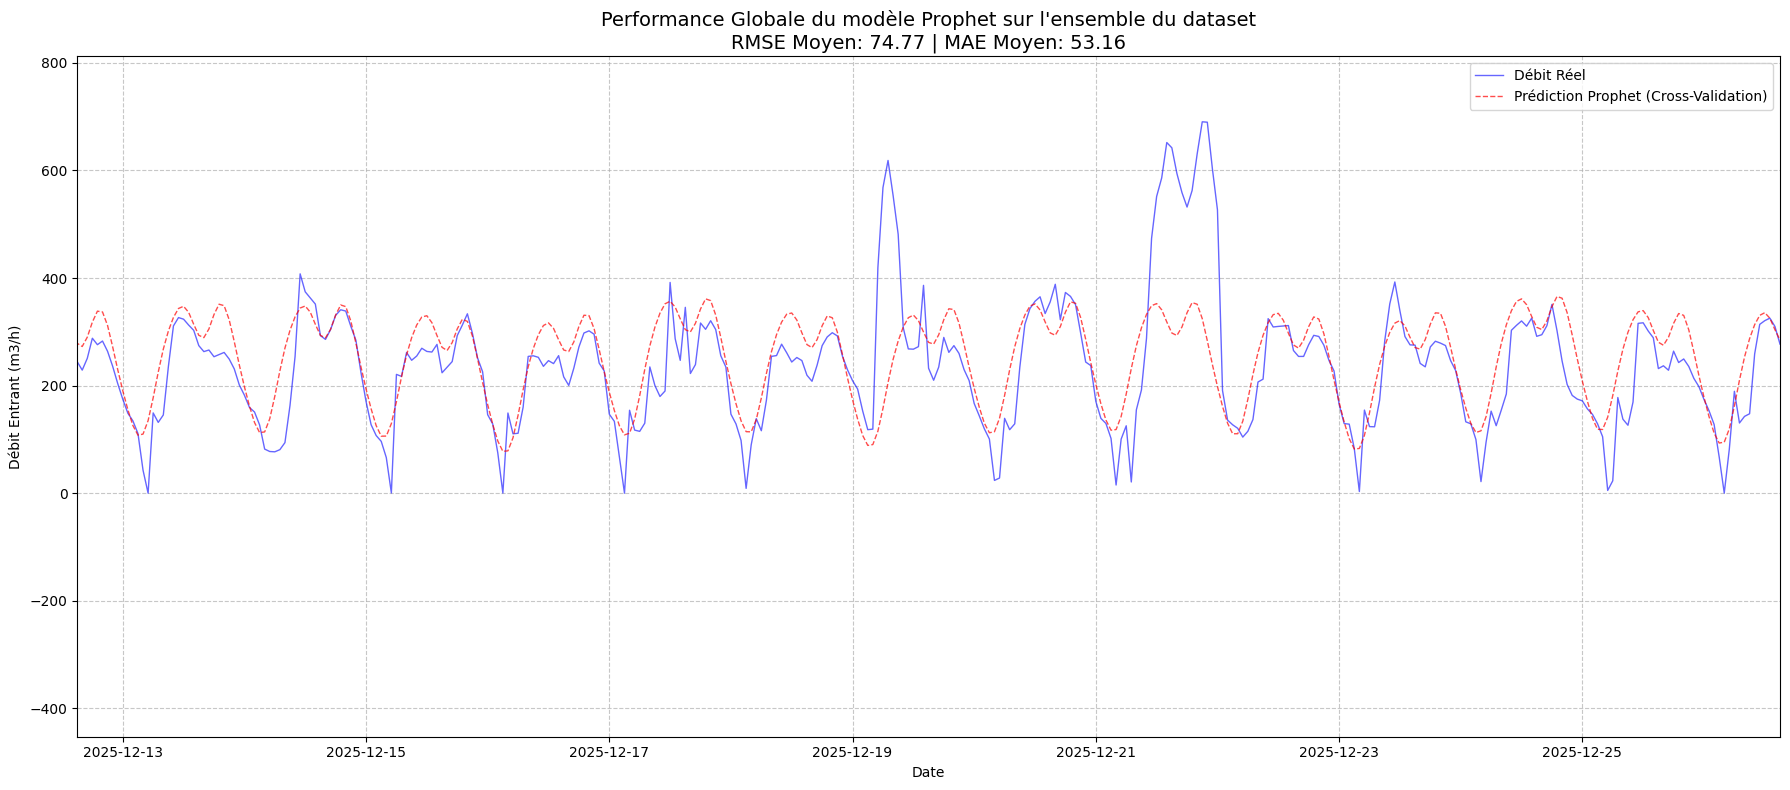

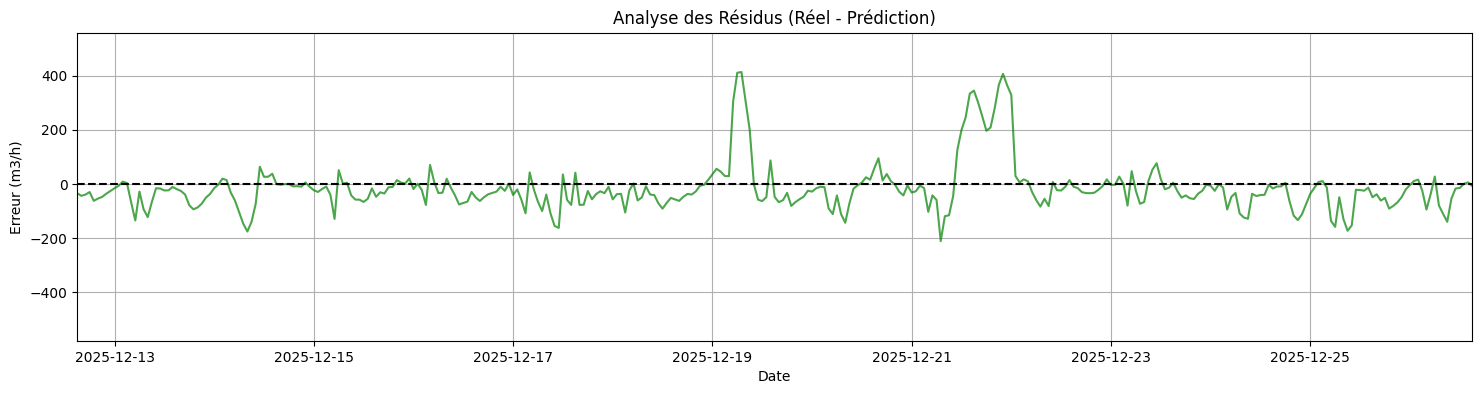

In [26]:
# --- 3. Visualisation ---
# Création d'un DataFrame global de résultats
df_results = pd.DataFrame({
    'Date': all_dates,
    'Réel': all_actuals,
    'Prédiction': all_predictions
}).set_index('Date').sort_index()

# Visualisation
plt.figure(figsize=(18, 8))

# On affiche les données réelles
plt.plot(df_results.index, df_results['Réel'], label='Débit Réel', color='blue', alpha=0.6, linewidth=1)

# On affiche les prédictions par dessus
plt.plot(df_results.index, df_results['Prédiction'], label='Prédiction Prophet (Cross-Validation)', color='red', alpha=0.7, linewidth=1, linestyle='--')

plt.title(f"Performance Globale du modèle Prophet sur l'ensemble du dataset\nRMSE Moyen: {np.mean(all_rmse_scores):.2f} | MAE Moyen: {np.mean(all_mae_scores):.2f}", fontsize=14)
plt.ylabel('Débit Entrant (m3/h)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Zoom sur les 2 dernières semaines
last_two_weeks = df_results.index.max() - pd.DateOffset(weeks=2)
plt.xlim(left=last_two_weeks, right=df_results.index.max())

plt.tight_layout()
plt.show()

# Focus sur les résidus (Erreurs)
plt.figure(figsize=(18, 4))
residus = df_results['Réel'] - df_results['Prédiction']
plt.plot(df_results.index, residus, color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title("Analyse des Résidus (Réel - Prédiction)")
plt.ylabel("Erreur (m3/h)")
plt.xlabel("Date")

plt.xlim(left=last_two_weeks, right=df_results.index.max())
plt.grid(True)
plt.show()

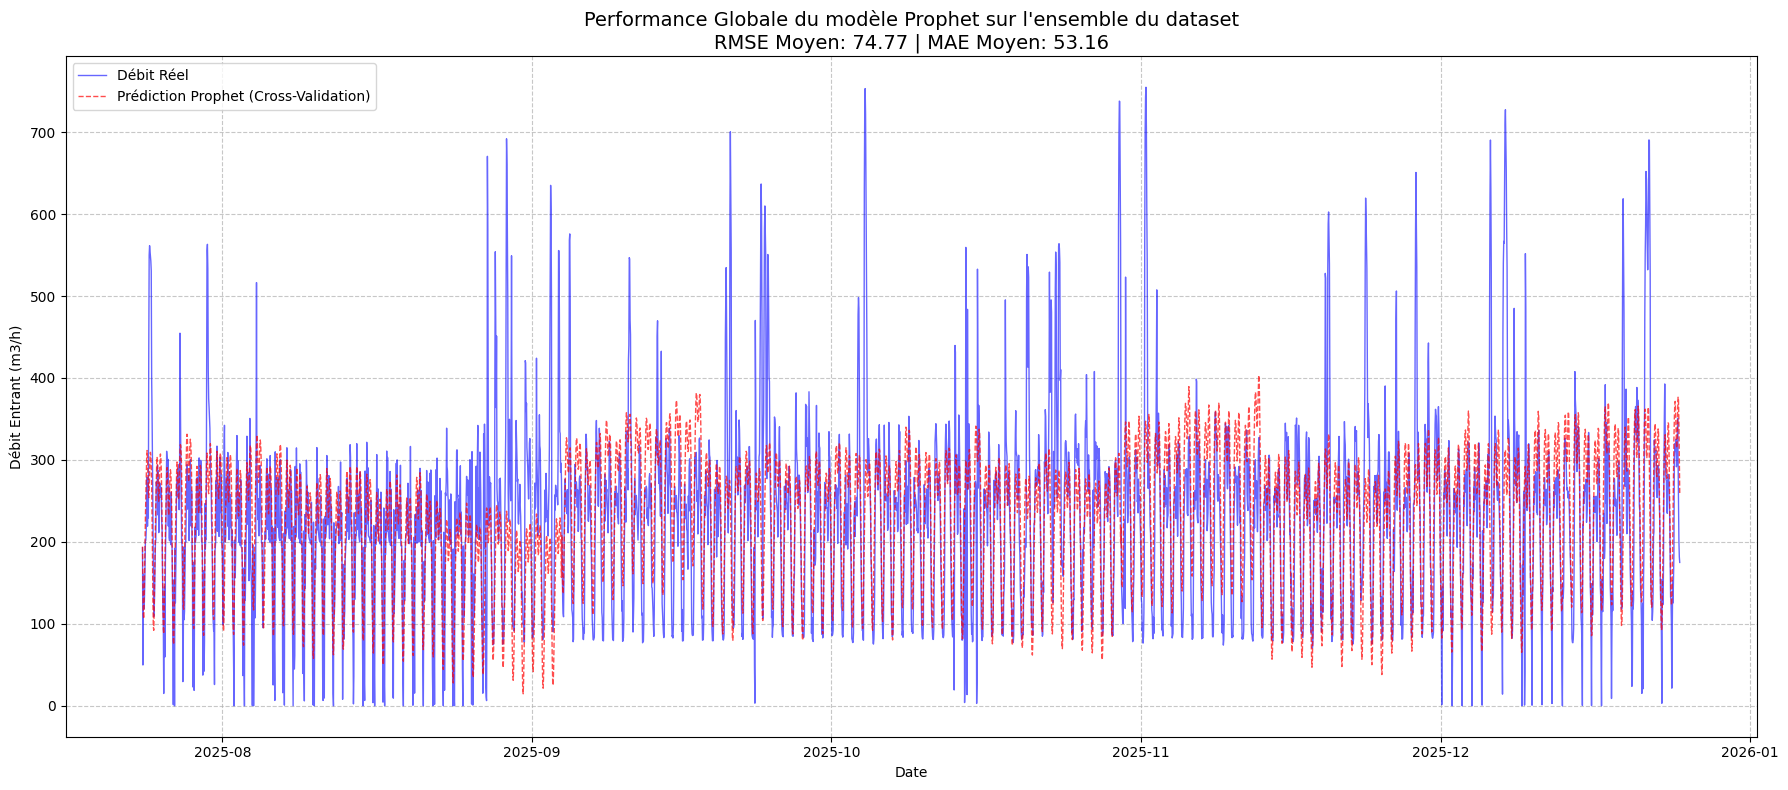

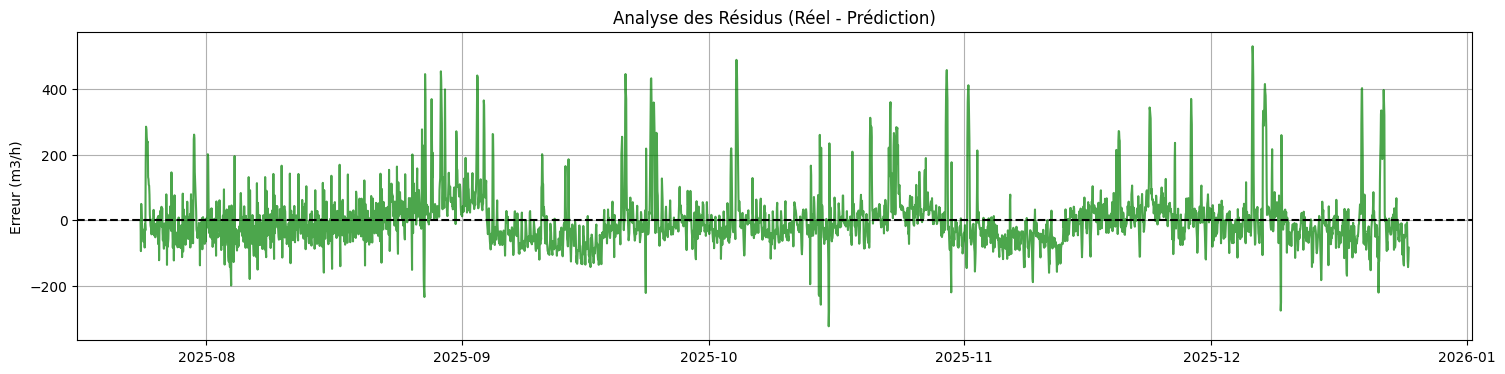

In [14]:
# --- 3. Visualisation ---
# Création d'un DataFrame global de résultats
df_results = pd.DataFrame({
    'Date': all_dates_adjusted,
    'Réel': all_actuals_adjusted,
    'Prédiction': all_predictions_adjusted
}).set_index('Date').sort_index()

# Visualisation
plt.figure(figsize=(18, 8))

# On affiche les données réelles
plt.plot(df_results.index, df_results['Réel'], label='Débit Réel', color='blue', alpha=0.6, linewidth=1)

# On affiche les prédictions par dessus
plt.plot(df_results.index, df_results['Prédiction'], label='Prédiction Prophet (Cross-Validation)', color='red', alpha=0.7, linewidth=1, linestyle='--')

plt.title(f"Performance Globale du modèle Prophet sur l'ensemble du dataset\nRMSE Moyen: {np.mean(all_rmse_scores):.2f} | MAE Moyen: {np.mean(all_mae_scores):.2f}", fontsize=14)
plt.ylabel('Débit Entrant (m3/h)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Zoom sur une période intéressante (ex: le dernier mois) pour mieux voir les détails
# Décommente les lignes ci-dessous pour zoomer
# last_month = df_results.index.max() - pd.DateOffset(months=1)
# plt.xlim(left=last_month)

plt.tight_layout()
plt.show()

# Focus sur les résidus (Erreurs)
plt.figure(figsize=(18, 4))
residus = df_results['Réel'] - df_results['Prédiction']
plt.plot(df_results.index, residus, color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title("Analyse des Résidus (Réel - Prédiction)")
plt.ylabel("Erreur (m3/h)")
plt.grid(True)
plt.show()

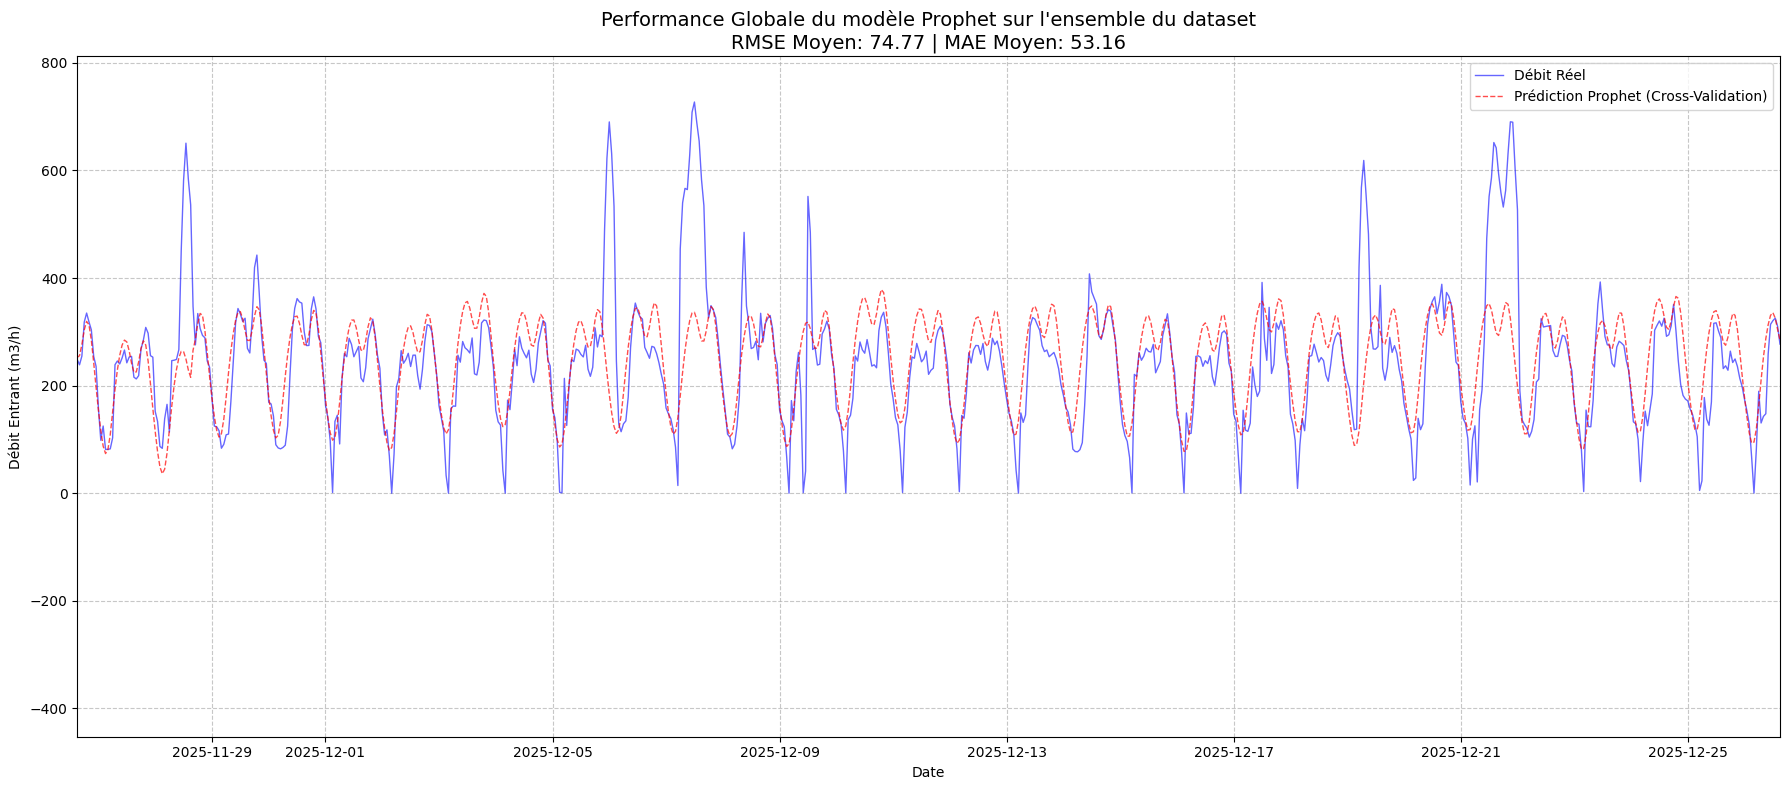

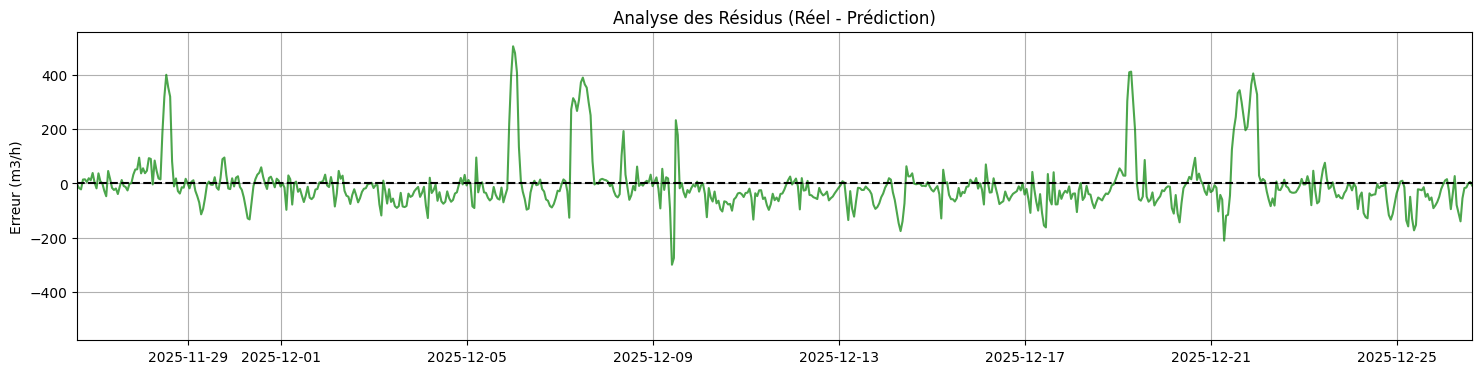

In [27]:
# --- 3. Visualisation ---
# Création d'un DataFrame global de résultats
df_results = pd.DataFrame({
    'Date': all_dates,
    'Réel': all_actuals,
    'Prédiction': all_predictions
}).set_index('Date').sort_index()

# Visualisation
plt.figure(figsize=(18, 8))

# On affiche les données réelles
plt.plot(df_results.index, df_results['Réel'], label='Débit Réel', color='blue', alpha=0.6, linewidth=1)

# On affiche les prédictions par dessus
plt.plot(df_results.index, df_results['Prédiction'], label='Prédiction Prophet (Cross-Validation)', color='red', alpha=0.7, linewidth=1, linestyle='--')

plt.title(f"Performance Globale du modèle Prophet sur l'ensemble du dataset\nRMSE Moyen: {np.mean(all_rmse_scores):.2f} | MAE Moyen: {np.mean(all_mae_scores):.2f}", fontsize=14)
plt.ylabel('Débit Entrant (m3/h)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Zoom sur une période intéressante (ex: le dernier mois) pour mieux voir les détails
# Décommente les lignes ci-dessous pour zoomer
last_month = df_results.index.max() - pd.DateOffset(months=1)
plt.xlim(left=last_month, right=df_results.index.max())

plt.tight_layout()
plt.show()

# Focus sur les résidus (Erreurs)
plt.figure(figsize=(18, 4))
residus = df_results['Réel'] - df_results['Prédiction']
plt.plot(df_results.index, residus, color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title("Analyse des Résidus (Réel - Prédiction)")
plt.ylabel("Erreur (m3/h)")
plt.grid(True)
plt.xlim(left=last_month, right=df_results.index.max())
plt.show()

# Station C

## Modèle servant de Baseline : SARIMA

### Chargement et préparation des données

In [ ]:
# --- 1. Chargement et Préparation ---
file_path = '../../Dataset/bronze/sensors_C_20250101_20260108.csv'

print("Chargement des données...")
df = pd.read_csv(file_path)

# Conversion de la date
date_col = 'ts'
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

# Sélection du signal unique
series = df.loc[df['sensor'] == 'entry_debit_f1', 'value']

# Rééchantillonnage horaire (Moyenne)
series_resampled = series.resample('1h').mean().ffill()

# Split Train / Test
# On garde 3 mois d'historique pour l'entraînement pour capter les dynamiques sans être trop lourd
three_months_ago = series_resampled.index.max() - pd.DateOffset(months=3)
series_recent = series_resampled[series_resampled.index >= three_months_ago]

test_size = 24 * 14 # Test sur 2 semaines (336 heures)
train = series_recent[:-test_size]
test = series_recent[-test_size:]

print(f"Train size: {len(train)} heures")
print(f"Test size: {len(test)} heures")

FileNotFoundError: [Errno 2] No such file or directory: './Dataset/bronze/sensor_P_20231110_20260106.csv'

### Grid Search SARIMAX

In [9]:
# --- 2. Grid Search SARIMAX (Saisonnalité Journalière) ---

# Définition de la grille
# Attention : SARIMAX avec s=24 est très lent. On limite l'espace de recherche.
# Ordre de tendance (Trend)
p_values = [1, 2]    # Auto-régressif court terme
d_values = [0, 1]    # Différenciation simple
q_values = [1, 2]    # Moyenne mobile

# Ordre saisonnier (Seasonal) - s=24 pour le cycle journalier
P_values = [0, 1]    # Auto-régressif saisonnier (ex: lien avec hier à la même heure)
D_values = [1]       # Différenciation saisonnière (quasi obligatoire pour le cycle 24h)
Q_values = [0, 1]    # Moyenne mobile saisonnière
s_value = 24         # Période de 24h

best_score = float("inf")
best_cfg = None
best_model = None

print(f"\nDémarrage de la Grid Search SARIMAX (s={s_value})...")
print("Cela peut prendre du temps en fonction de la puissance de calcul.")

# Création de toutes les combinaisons
combinations = list(product(p_values, d_values, q_values, P_values, D_values, Q_values))
total_combos = len(combinations)

start_time = time.time()

for i, (p, d, q, P, D, Q) in enumerate(combinations):
    order = (p, d, q)
    seasonal_order = (P, D, Q, s_value)
    
    try:
        # Affichage de progression
        if i % 5 == 0:
            print(f"Test combinaison {i}/{total_combos} : {order} x {seasonal_order}...")

        model = SARIMAX(train, 
                        order=order, 
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
        
        # disp=False pour ne pas polluer la console
        model_fit = model.fit(disp=False, maxiter=50) 
        
        # Prédiction
        forecast = model_fit.get_forecast(steps=len(test))
        predictions = forecast.predicted_mean
        
        # Évaluation RMSE
        rmse = np.sqrt(mean_squared_error(test, predictions))
        
        if rmse < best_score:
            best_score = rmse
            best_cfg = (order, seasonal_order)
            best_model = model_fit
            print(f"--> NOUVEAU RECORD : RMSE={rmse:.3f} avec {order}x{seasonal_order}")

    except Exception as e:
        continue

elapsed_time = (time.time() - start_time) / 60
print(f"\nTerminé en {elapsed_time:.1f} minutes.")
print(f'Meilleur Modèle : SARIMAX{best_cfg} RMSE={best_score:.3f}')


Démarrage de la Grid Search SARIMAX (s=24)...
Cela peut prendre du temps en fonction de la puissance de calcul.
Test combinaison 0/32 : (1, 0, 1) x (0, 1, 0, 24)...
--> NOUVEAU RECORD : RMSE=46.750 avec (1, 0, 1)x(0, 1, 0, 24)
--> NOUVEAU RECORD : RMSE=40.913 avec (1, 0, 1)x(1, 1, 0, 24)
Test combinaison 5/32 : (1, 0, 2) x (0, 1, 1, 24)...
Test combinaison 10/32 : (1, 1, 1) x (1, 1, 0, 24)...
Test combinaison 15/32 : (1, 1, 2) x (1, 1, 1, 24)...
Test combinaison 20/32 : (2, 0, 2) x (0, 1, 0, 24)...
Test combinaison 25/32 : (2, 1, 1) x (0, 1, 1, 24)...
Test combinaison 30/32 : (2, 1, 2) x (1, 1, 0, 24)...

Terminé en 2.1 minutes.
Meilleur Modèle : SARIMAX((1, 0, 1), (1, 1, 0, 24)) RMSE=40.913


### Visualisation

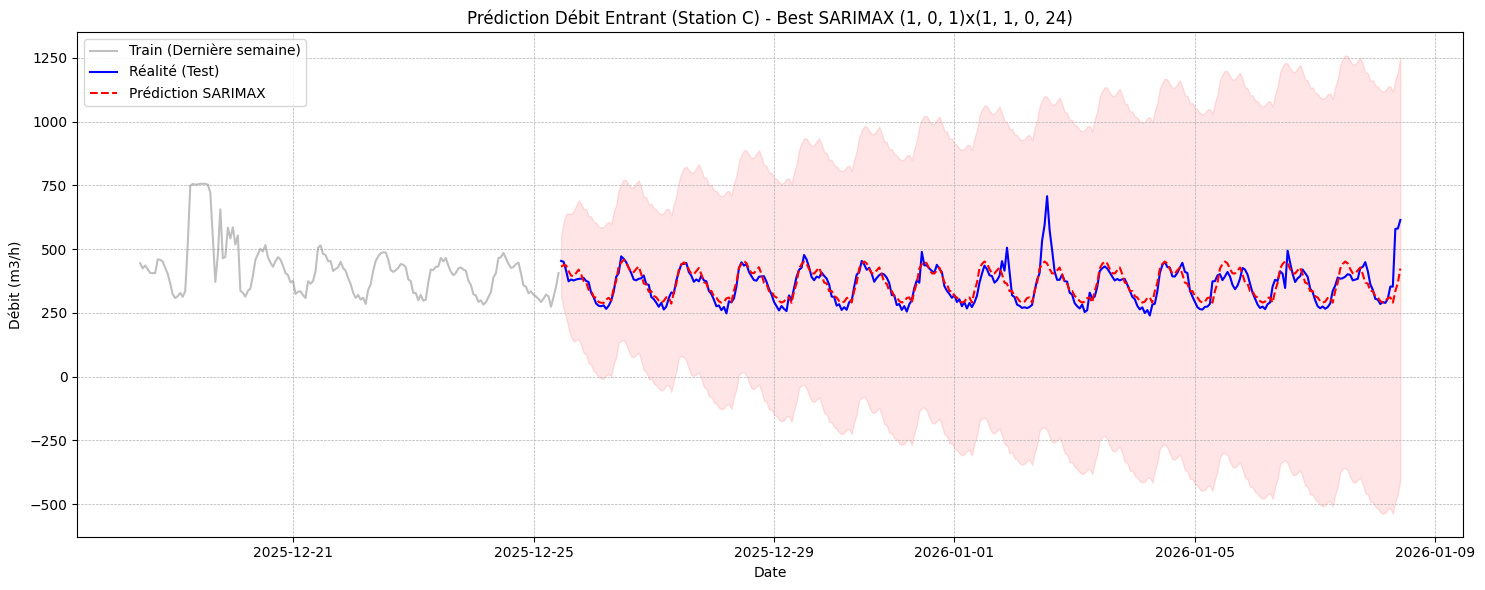

In [10]:
# --- 3. Visualisation ---
final_forecast = best_model.get_forecast(steps=len(test))
final_predictions = final_forecast.predicted_mean
conf_int = final_forecast.conf_int()

plt.figure(figsize=(15, 6))

# On affiche la fin du train
plt.plot(train.index[-168:], train[-168:], label='Train (Dernière semaine)', color='gray', alpha=0.5)

# La réalité
plt.plot(test.index, test, label='Réalité (Test)', color='blue', linewidth=1.5)

# La prédiction
plt.plot(test.index, final_predictions, label='Prédiction SARIMAX', color='red', linestyle='--', linewidth=1.5)

# Intervalle de confiance (optionnel mais utile)
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1)

plt.title(f"Prédiction Débit Entrant (Station C) - Best SARIMAX {best_cfg[0]}x{best_cfg[1]}")
plt.ylabel("Débit (m3/h)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### Métriques

In [11]:
# --- 4. Métriques ---
mae = mean_absolute_error(test, final_predictions)
print("\n--- Résultats Finaux ---")
print(f"Meilleurs Paramètres : Order={best_cfg[0]}, Seasonal={best_cfg[1]}")
print(f"RMSE : {best_score:.2f} m3/h")
print(f"MAE  : {mae:.2f} m3/h")


--- Résultats Finaux ---
Meilleurs Paramètres : Order=(1, 0, 1), Seasonal=(1, 1, 0, 24)
RMSE : 40.91 m3/h
MAE  : 27.31 m3/h
